Figure saved → neighbourhood_PrtStatMem.png


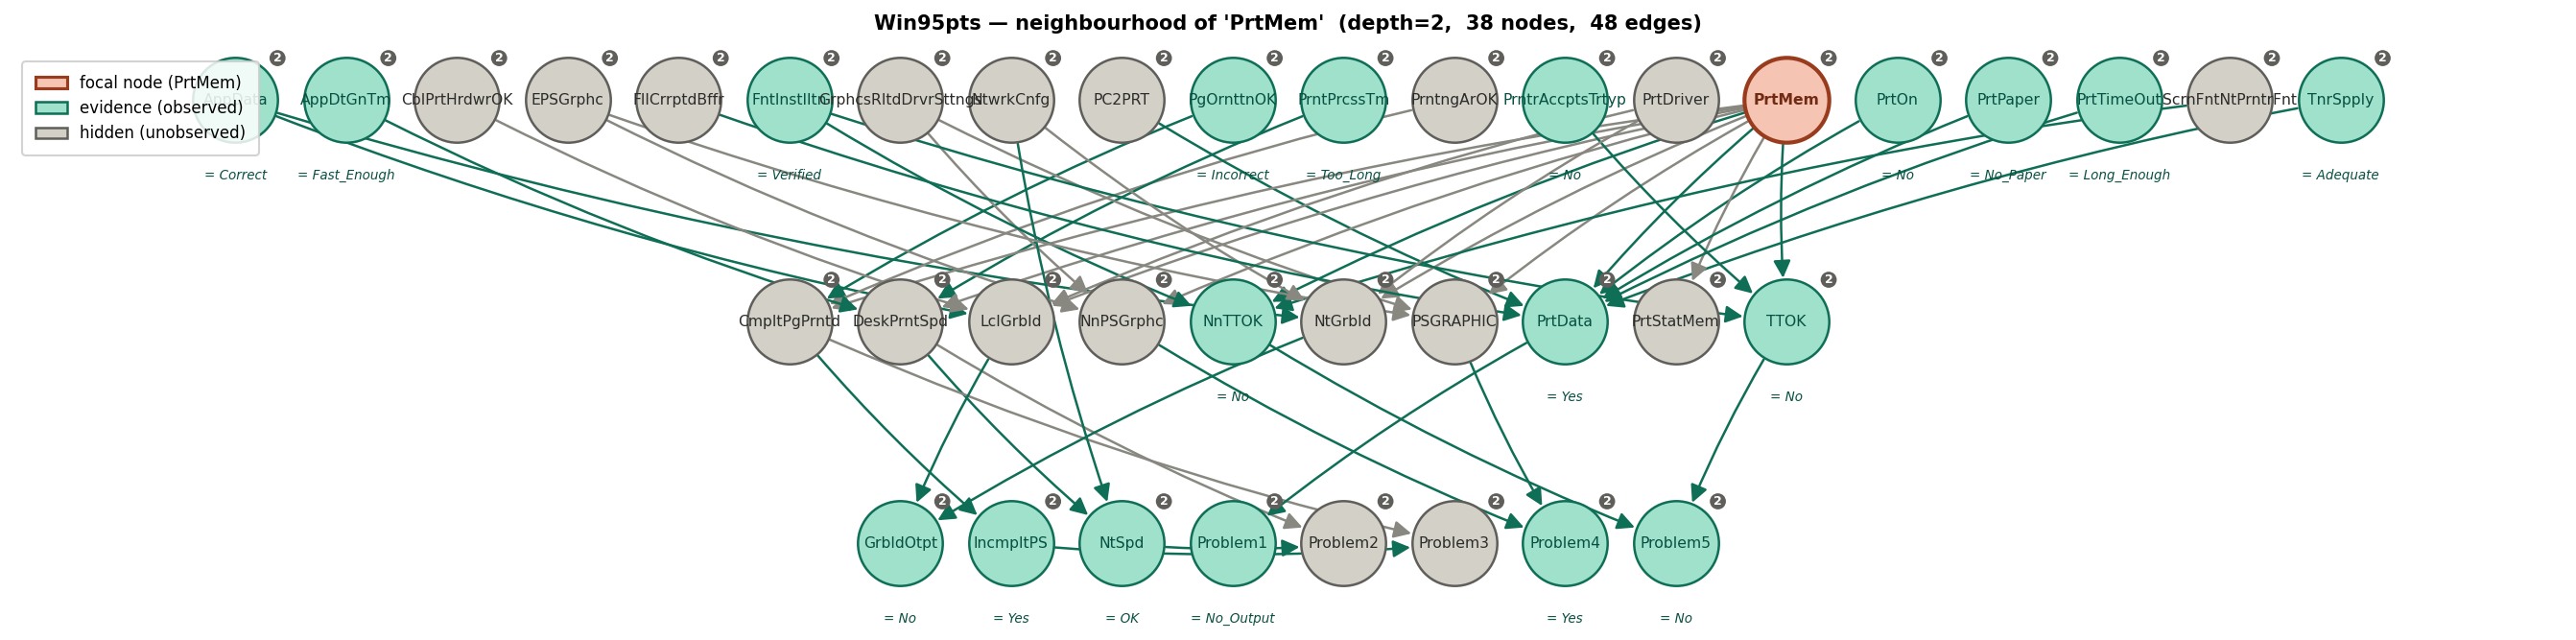

In [3]:
"""
plot_bn_neighbourhood.py
-------------------------
Plots the local topology of a BayesianNetwork around a focal node.

Usage
-----
    from plot_bn_neighbourhood import plot_bn_neighbourhood
    from pgmpy.utils import get_example_model

    bn = get_example_model('win95pts')
    evidence = {'TTOK': 'No', ...}   # your patient dict

    fig = plot_bn_neighbourhood(
        bn,
        focal_node='PrtStatMem',
        evidence=evidence,
        depth=2,
        save_path='neighbourhood.png',
    )
    plt.show()

Node colours
------------
  - focal node   : coral  (the node you asked about)
  - evidence     : teal   (observed in the patient)
  - hidden       : gray   (unobserved)

Edge colours
------------
  - edges involving only hidden/focal nodes  : neutral gray
  - edges where the child is evidence        : teal
  - edges where the parent is evidence       : muted teal
"""

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import numpy as np
import warnings
warnings.filterwarnings("ignore")


# ── Colour constants (match the publication palette) ─────────────────────────
C_FOCAL   = {'face': '#F5C4B3', 'edge': '#993C1D', 'text': '#712B13'}  # coral
C_EVIDENCE= {'face': '#9FE1CB', 'edge': '#0F6E56', 'text': '#085041'}  # teal
C_HIDDEN  = {'face': '#D3D1C7', 'edge': '#5F5E5A', 'text': '#2C2C2A'}  # gray


def _collect_neighbourhood(bn, focal_node, depth):
    """
    Return the set of nodes within `depth` hops of `focal_node`
    in the undirected sense (ancestors + descendants).
    """
    nodes = {focal_node}
    frontier = {focal_node}
    for _ in range(depth):
        nxt = set()
        for n in frontier:
            nxt.update(bn.get_parents(n))
            nxt.update(bn.get_children(n))
        new = nxt - nodes
        nodes.update(new)
        frontier = new
    return nodes


def _layout(bn, nodes, focal_node):
    """
    Hierarchical layout: ancestors above focal, descendants below.
    Within each tier, nodes are spread horizontally.

    Returns dict {node: (x, y)} with y increasing downward.
    """
    # Assign tier by BFS from focal (signed: ancestors = negative, descendants = positive)
    tier = {focal_node: 0}
    queue = [focal_node]
    while queue:
        n = queue.pop(0)
        for p in bn.get_parents(n):
            if p in nodes and p not in tier:
                tier[p] = tier[n] - 1
                queue.append(p)
        for c in bn.get_children(n):
            if c in nodes and c not in tier:
                tier[c] = tier[n] + 1
                queue.append(c)

    # For any node not yet reached (disconnected in directed sense), assign tier 0
    for n in nodes:
        if n not in tier:
            tier[n] = 0

    # Group by tier
    tiers = {}
    for n, t in tier.items():
        tiers.setdefault(t, []).append(n)

    # Sort nodes within each tier alphabetically for stability
    for t in tiers:
        tiers[t].sort()

    # Assign (x, y): y = tier * tier_gap, x = evenly spaced
    TIER_GAP = 2.0
    pos = {}
    for t, tier_nodes in tiers.items():
        n = len(tier_nodes)
        xs = np.linspace(-(n - 1) / 2.0, (n - 1) / 2.0, n)
        for node, x in zip(tier_nodes, xs):
            pos[node] = (float(x), float(-t * TIER_GAP))

    return pos


def plot_bn_neighbourhood(
    bn,
    focal_node,
    evidence=None,
    depth=2,
    figsize=None,
    save_path=None,
    dpi=150,
    title=None,
):
    """
    Plot the local topology of `bn` around `focal_node`.

    Parameters
    ----------
    bn          : pgmpy BayesianNetwork
    focal_node  : str   — centre of the diagram
    evidence    : dict  — patient / observation dict (keys = observed nodes)
    depth       : int   — hops in either direction to include (default 2)
    figsize     : tuple — (width, height) in inches; auto-sized if None
    save_path   : str   — if given, saves PNG/PDF to this path
    dpi         : int   — output resolution
    title       : str   — figure title; auto-generated if None

    Returns
    -------
    fig : matplotlib.figure.Figure
    """
    evidence = evidence or {}
    evidence_set = set(evidence.keys())

    # ── Collect neighbourhood ─────────────────────────────────────────────
    nodes = _collect_neighbourhood(bn, focal_node, depth)

    # Build subgraph of directed edges within neighbourhood
    edges = [(u, v) for u, v in bn.edges()
             if u in nodes and v in nodes]

    # ── Layout ────────────────────────────────────────────────────────────
    pos = _layout(bn, nodes, focal_node)

    # ── Node roles ────────────────────────────────────────────────────────
    def node_role(n):
        if n == focal_node:    return 'focal'
        if n in evidence_set:  return 'evidence'
        return 'hidden'

    # ── Figure ────────────────────────────────────────────────────────────
    n_nodes = len(nodes)
    if figsize is None:
        w = max(8, n_nodes * 0.9)
        h = max(5, n_nodes * 0.55)
        figsize = (min(w, 18), min(h, 12))

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    ax.set_aspect('equal')
    ax.axis('off')

    # ── Draw edges ────────────────────────────────────────────────────────
    G = nx.DiGraph()
    G.add_nodes_from(nodes)
    G.add_edges_from(edges)

    # Colour each edge by the role of its endpoints
    edge_colors = []
    for u, v in G.edges():
        if node_role(v) == 'evidence' or node_role(u) == 'evidence':
            edge_colors.append(C_EVIDENCE['edge'])
        else:
            edge_colors.append('#888780')

    nx.draw_networkx_edges(
        G, pos, ax=ax,
        edge_color=edge_colors,
        arrows=True,
        arrowstyle='-|>',
        arrowsize=18,
        width=1.2,
        connectionstyle='arc3,rad=0.05',
        min_source_margin=22,
        min_target_margin=22,
    )

    # ── Draw nodes ────────────────────────────────────────────────────────
    NODE_SIZE = 1800
    for n in nodes:
        role = node_role(n)
        c = {'focal': C_FOCAL, 'evidence': C_EVIDENCE, 'hidden': C_HIDDEN}[role]
        nx.draw_networkx_nodes(
            G, pos, nodelist=[n], ax=ax,
            node_size=NODE_SIZE,
            node_color=c['face'],
            edgecolors=c['edge'],
            linewidths=2.0 if role == 'focal' else 1.2,
            node_shape='o',
        )

    # ── Labels ────────────────────────────────────────────────────────────
    # Wrap long node names at underscores for readability
    def wrap(name, maxlen=12):
        parts = name.split('_')
        lines, cur = [], ''
        for p in parts:
            candidate = (cur + '_' + p).lstrip('_')
            if len(candidate) > maxlen and cur:
                lines.append(cur)
                cur = p
            else:
                cur = candidate
        if cur:
            lines.append(cur)
        return '\n'.join(lines)

    label_dict = {n: wrap(n) for n in nodes}
    label_colors = {
        n: C_FOCAL['text']    if node_role(n) == 'focal'
           else C_EVIDENCE['text'] if node_role(n) == 'evidence'
           else C_HIDDEN['text']
        for n in nodes
    }

    for n, (x, y) in pos.items():
        ax.text(
            x, y, label_dict[n],
            ha='center', va='center',
            fontsize=7.5, fontweight='bold' if n == focal_node else 'normal',
            color=label_colors[n],
            multialignment='center',
            zorder=5,
        )

    # ── Evidence values as small annotations ─────────────────────────────
    for n in nodes:
        if n in evidence_set:
            x, y = pos[n]
            val = str(evidence[n])
            if len(val) > 14:
                val = val[:13] + '…'
            ax.text(
                x, y - 0.62, f'= {val}',
                ha='center', va='top',
                fontsize=6.5, color=C_EVIDENCE['text'],
                style='italic', zorder=5,
            )

    # ── Cardinality badges ────────────────────────────────────────────────
    for n in nodes:
        card = bn.get_cpds(n).variable_card
        x, y = pos[n]
        ax.text(
            x + 0.38, y + 0.38, str(card),
            ha='center', va='center',
            fontsize=6, color='white',
            fontweight='bold',
            bbox=dict(boxstyle='circle,pad=0.15',
                      fc=C_HIDDEN['edge'], ec='none'),
            zorder=6,
        )

    # ── Legend ────────────────────────────────────────────────────────────
    legend_handles = [
        mpatches.Patch(fc=C_FOCAL['face'],    ec=C_FOCAL['edge'],
                       linewidth=1.5, label=f'focal node ({focal_node})'),
        mpatches.Patch(fc=C_EVIDENCE['face'], ec=C_EVIDENCE['edge'],
                       linewidth=1.2, label='evidence (observed)'),
        mpatches.Patch(fc=C_HIDDEN['face'],   ec=C_HIDDEN['edge'],
                       linewidth=1.2, label='hidden (unobserved)'),
    ]
    ax.legend(
        handles=legend_handles, loc='upper left',
        fontsize=8, framealpha=0.85,
        edgecolor='#ccc', borderpad=0.8,
    )

    # ── Title ─────────────────────────────────────────────────────────────
    if title is None:
        title = (f"Win95pts — neighbourhood of '{focal_node}'  "
                 f"(depth={depth},  {len(nodes)} nodes,  {len(edges)} edges)")
    ax.set_title(title, fontsize=10, fontweight='bold', pad=12)

    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches='tight')
        print(f"Figure saved → {save_path}")

    return fig


# ── Entry point ───────────────────────────────────────────────────────────────
if __name__ == '__main__':
    from pgmpy.utils import get_example_model

    bn = get_example_model('win95pts')

    interesting_patient = {
        'TTOK': 'No', 'NtSpd': 'OK', 'PgOrnttnOK': 'Incorrect', 'NetOK': 'Yes',
        'TrTypFnts': 'No', 'PrtPath': 'Correct', 'PrtPaper': 'No_Paper',
        'Problem1': 'No_Output', 'AppData': 'Correct', 'PrtDataOut': 'Yes',
        'PSERRMEM': 'Low_Memory', 'Problem4': 'Yes', 'FntInstlltn': 'Verified',
        'NnTTOK': 'No', 'AppDtGnTm': 'Fast_Enough',
        'DskLocal': 'Greater_than_2_Mb', 'PrtSel': 'Yes', 'Problem5': 'No',
        'IncmpltPS': 'Yes', 'PrtIcon': 'Normal', 'GDIIN': 'Yes',
        'PrtData': 'Yes', 'PrtPScript': 'Yes',
        'HrglssDrtnAftrPrnt': 'Fast_Enough', 'AvlblVrtlMmry': 'Adequate____1Mb_',
        'PrtPort': 'Yes', 'GrbldOtpt': 'No', 'GDIOUT': 'Yes',
        'TnrSpply': 'Adequate', 'PrntrAccptsTrtyp': 'No', 'PrtOn': 'No',
        'Problem6': 'No', 'PrtSpool': 'Disabled',
        'TstpsTxt': 'x_1_Mb_Available_VM', 'PrtTimeOut': 'Long_Enough',
        'PrntPrcssTm': 'Too_Long', 'PrtStatToner': 'Low__None', 'DrvSet': 'Correct',
    }

    fig = plot_bn_neighbourhood(
        bn,
        focal_node='PrtMem',
        evidence=interesting_patient,
        depth=2,
        save_path='neighbourhood_PrtStatMem.png',
    )
    plt.show()